# **Pronósticos con Series de Tiempo**

In this notebook we explore different models in a simple way to analyze time series

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error as rmse
from prophet import Prophet
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf   # gráficos de autocorrelación
from statsmodels.tsa.arima.model import ARIMA


In [5]:
df = pd.read_csv('monthly_champagne_sales.csv')
df.columns = ['ds', 'y']
df['ds']= pd.to_datetime(df['ds'])

df.head()

,ds,y
0,1964-01-01,2815
1,1964-02-01,2672
2,1964-03-01,2755
3,1964-04-01,2721
4,1964-05-01,2946


In [11]:
df_temp = df.copy()
df_temp.set_index('ds', inplace=True)
print(df.shape)
print(df_temp.shape)
print(df_temp.index)

(105, 2)
(105, 1)
DatetimeIndex(['1964-01-01', '1964-02-01', '1964-03-01', '1964-04-01',
               '1964-05-01', '1964-06-01', '1964-07-01', '1964-08-01',
               '1964-09-01', '1964-10-01',
               ...
               '1971-12-01', '1972-01-01', '1972-02-01', '1972-03-01',
               '1972-04-01', '1972-05-01', '1972-06-01', '1972-07-01',
               '1972-08-01', '1972-09-01'],
              dtype='datetime64[ns]', name='ds', length=105, freq=None)


* Define monthly frequency

In [15]:
df_temp.index.freq= 'MS' # Establece la frecuencia mensual
df_temp.index

DatetimeIndex(['1964-01-01', '1964-02-01', '1964-03-01', '1964-04-01',
               '1964-05-01', '1964-06-01', '1964-07-01', '1964-08-01',
               '1964-09-01', '1964-10-01',
               ...
               '1971-12-01', '1972-01-01', '1972-02-01', '1972-03-01',
               '1972-04-01', '1972-05-01', '1972-06-01', '1972-07-01',
               '1972-08-01', '1972-09-01'],
              dtype='datetime64[ns]', name='ds', length=105, freq='MS')

* Split on train and test data. 

In [17]:
train = df_temp.iloc[0:-12,:]

test = df_temp.iloc[-12:,:] 
print(train.shape, test.shape)

(93, 1) (12, 1)


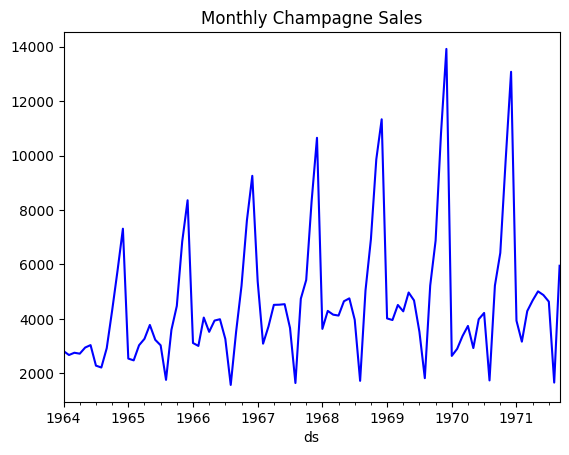

In [18]:
# Gráfico con la periodicidad mensual:
train['y'].plot(title='Monthly Champagne Sales', style='-b')
plt.show()

There is a clear path in the sales through every year.

### **Dummy Model**

This model will serve as a baseline for the other models developed.
We will use the root mean square error (RMSE) as the performance measure.

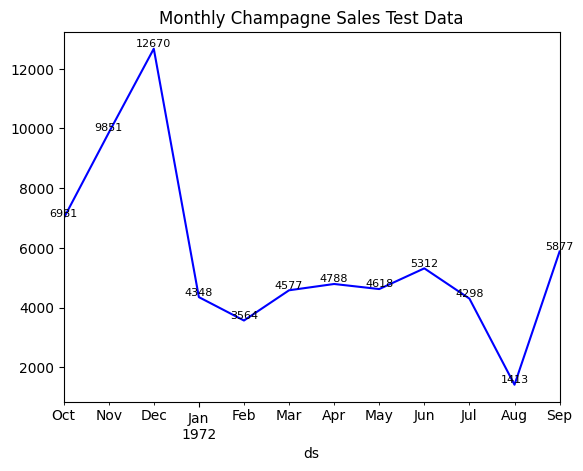

In [21]:
ax = test['y'].plot(title='Monthly Champagne Sales Test Data', style='-b')
for i, value in enumerate(test['y']):
    ax.text(test.index[i], value, f'{value:.0f}', color='black', fontsize=8, ha='center', va='bottom')

plt.show()

In [ ]:
history = [x for x in train['y'].values]  
predictions = list()  

for i in range(len(test['y'])):
  # Obtain predictions:
  yhat = history[-1] 
  predictions.append(yhat)

  # Real data:
  obs = test.iloc[i]['y']   
  history.append(obs)  
  print('>Esperado-real = %3d, Predicción = %.3f' % (obs, yhat))


# Calculate the root mean squared error (RMSE):
rmse = np.sqrt(mean_squared_error(test['y'].values, predictions))
print('\nError-Modelo-Naive: RMSE: %.3f' % rmse)

>Esperado-real = 6981, Predicción = 5951.000
>Esperado-real = 9851, Predicción = 6981.000
>Esperado-real = 12670, Predicción = 9851.000
>Esperado-real = 4348, Predicción = 12670.000
>Esperado-real = 3564, Predicción = 4348.000
>Esperado-real = 4577, Predicción = 3564.000
>Esperado-real = 4788, Predicción = 4577.000
>Esperado-real = 4618, Predicción = 4788.000
>Esperado-real = 5312, Predicción = 4618.000
>Esperado-real = 4298, Predicción = 5312.000
>Esperado-real = 1413, Predicción = 4298.000
>Esperado-real = 5877, Predicción = 1413.000

Error-Modelo-Naive: RMSE: 3135.480


In [24]:
test['y'].describe()

count       12.000000
mean      5691.416667
std       2979.194841
min       1413.000000
25%       4335.500000
50%       4703.000000
75%       6153.000000
max      12670.000000
Name: y, dtype: float64

We observe that the mean square error of the model is 3,135,480 monthly sales, which is a fairly large error considering that the average of the test data values ​​is 5691.41.

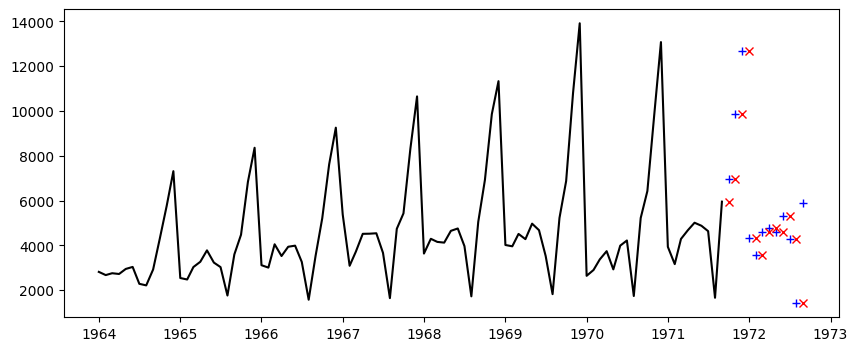

In [25]:
fig, ax = plt.subplots(figsize=(10, 4))
ax = plt.plot(train['y'], '-k')  # Datos de entrenamiento de 1949 a 1959 (los históricos).
ax = plt.plot(test['y'], '+b')    # Datos de prueba reales del año 1960 (los del útimo año a predecir).
ax = plt.plot(test.index, predictions, 'xr')  # Predicciones del modelo ingenuo para el último año 1960.

Taking a closer look at the plot of test data vs predicted values ​​we get the following:

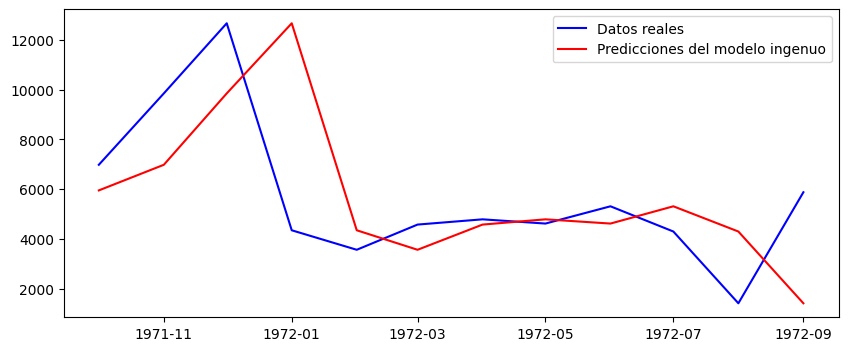

In [29]:

fig, ax = plt.subplots(figsize=(10, 4))
  # Datos de entrenamiento de 1949 a 1959 (los históricos).
ax = plt.plot(test['y'], color= 'blue')    # Datos de prueba reales del año 1960 (los del útimo año a predecir).
ax = plt.plot(test.index, predictions, color='red')
plt.legend(['Datos reales', 'Predicciones del modelo ingenuo'])
plt.show()# Predicciones del modelo ingenuo para el último año 1960.

##### **We display the decomposition graph of the time series into its trend, seasonality and residual components.**

### **ARIMA Model**

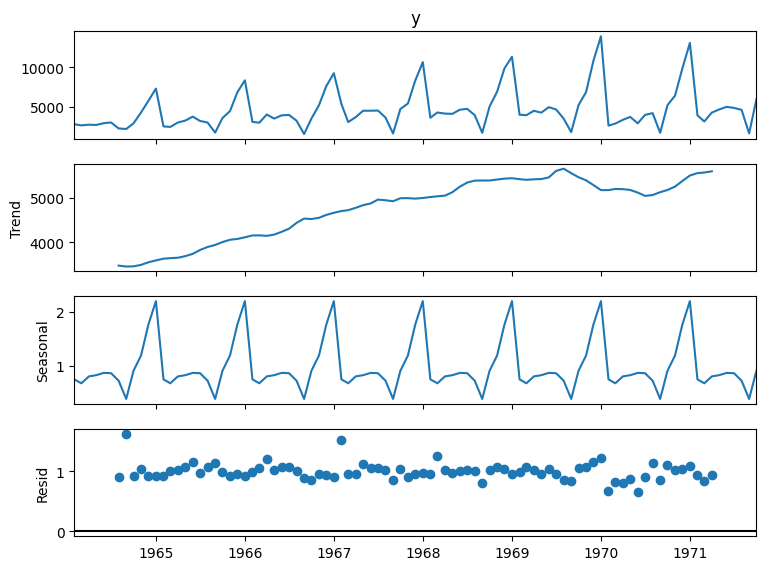

In [32]:
decomposition = seasonal_decompose(train['y'].resample('M').mean(), model='multiplicative')  # <<<---- Observa que el modelo es multiplicativo
fig = decomposition.plot()
fig.set_size_inches(8,6)
plt.show()


# ✅ .resample('M').mean()
# Aquí se está re-muestreando (resampling) la serie temporal para que tenga frecuencia mensual ('M' = fin de mes).
# Si tus datos originales son diarios o semanales, este paso agrupa los datos por mes.
# Luego se calcula el promedio de los valores de y para cada mes con .mean().

The seasonality graph confirms what we defined at the beginning of the analysis. The residual graph shows us that using the multiplicative model the values ​​are close to 1, unlike an additive model in which the ranges of values ​​are in the same dimension as the values ​​recorded in the dataset.

### Autocorrelation tests

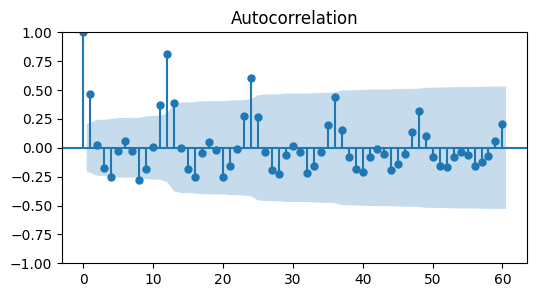

In [36]:
fig,ax = plt.subplots(figsize = (6,3))
plot_acf(train['y'], lags=60, ax=ax)
plt.show()  

There are autocorrelations significantly different from zero in the first lags (for example in lags 1, 2, 3 and other more dispersed ones). A pattern where autocorrelations slowly decay or remain significant over several lags is usually a sign of an MA (Moving Average) component. If the lags suddenly drop to zero after one or two lags, it could suggest a low-order MA model.

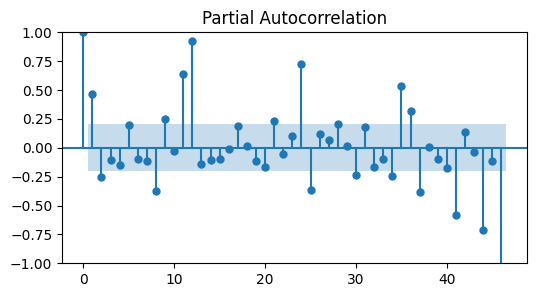

In [37]:
# Gráfico de Autocorrelación Parcial (PACF):
fig, ax = plt.subplots(figsize = (6,3))
plot_pacf(train['y'], lags = 46, ax = ax, method="ols")   # ols: regression of time series on lags of it an on constant. predetrminado method="ywm"
plt.show()

A high value is seen at lag 1, perhaps also at lag 2, and then the values ​​tend to be small and within the area of ​​non-significance (white noise). If the PACF shows a clear cutoff after a lag (for example, significant at lag 1 and then zero), it suggests an AR (AutoRegressive) model of that order (p=1 or 2)

In [ ]:
# Diferencia de datos consecutivos en el tiempo
# y podemos ahora usar ARIMA:
def difference(dataset, interval=1):
    """
Makes the difference between the time series values ​​- 1 and the current value. 
This helps remove trend and seasonality from the data. 
Args: 
dataset (_type_): _description_ 
interval (int, optional): _description_. Defaults to 1. 

Returns: 
_type_: _description_
    """
    diff = list()

    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)

    return np.array(diff)



# Invierte las diferencias anteriores, es decir, nos regresa la estacionalidad:
def inverse_difference(history, yhat, interval=1):
  return yhat + history[-interval]


In [45]:
history = [x for x in train.loc[:,'y'].values]   # train-ndarray : columna solo con los registros de ventas "y".
                               # history-list : lista con los datos del train.

predictions = list()   # Para incluir las predicciones que vaya generando el modelo.

for i in range(len(test['y'])):
  #
  months_in_year = 12 # Se toma como punto de partida para la diferencia de los datos de test
  diff = difference(history, months_in_year)    # diff-list: lista de los datos de diferencias para transformar SARIMA en ARIMA.

  # Generamos el modelo.
  model = ARIMA(diff, order=(2,0,1),) # Si aplicamos diff, entonces d=0 es aplicable.
  model_fit = model.fit(method_kwargs={'maxiter':300})  # Aumentar las iteraciones para evitar el WarningConvergence.

  yhat = model_fit.forecast()[0]   # prediccions (yhat) de cada registro, es un solo número flotante.
  yhat = inverse_difference(history, yhat, months_in_year)    # El "history" sigue siendo la lista de arriba.
                                                              # El nuevo "yhat" es cada un nuevo valor (float) de predicción.
  predictions.append(yhat)  # predictions-list : lista que se va incrementando al ir agregando cada predicción nueva.

  # Observaciones-reales:
  obs = test.iloc[i]['y']   #  cada dato es un flotante.
  history.append(obs)   #  history-list : se va incrementado a partir del Train con los registros-observaciones reales.

  print('>Esperado-real = %3d, Predicción = %.3f' % (obs, yhat))

# Error RMSE:
rmse = np.sqrt(mean_squared_error(test['y'].values, predictions))
print('\nError-Modelo-ARIMA: RMSE: %.3f' % rmse)

>Esperado-real = 6981, Predicción = 6817.269
>Esperado-real = 9851, Predicción = 10230.949
>Esperado-real = 12670, Predicción = 13354.302
>Esperado-real = 4348, Predicción = 4092.979
>Esperado-real = 3564, Predicción = 3453.459
>Esperado-real = 4577, Predicción = 4603.168
>Esperado-real = 4788, Predicción = 4981.823
>Esperado-real = 4618, Predicción = 5278.687
>Esperado-real = 5312, Predicción = 5026.703
>Esperado-real = 4298, Predicción = 4924.605
>Esperado-real = 1413, Predicción = 1821.769
>Esperado-real = 5877, Predicción = 6094.069

Error-Modelo-ARIMA: RMSE: 395.779


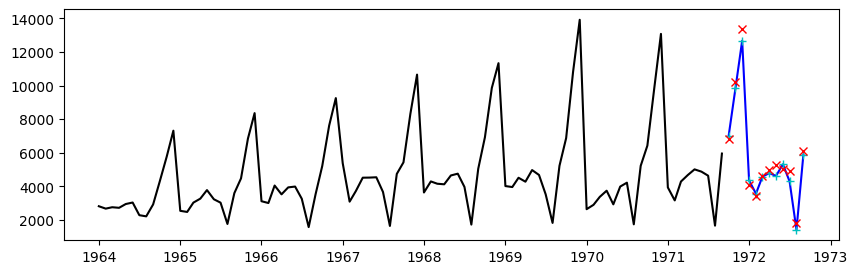

In [47]:
fig, ax = plt.subplots(figsize=(10, 3))
ax = plt.plot(train['y'], '-k')
ax = plt.plot(test['y'], '-b')
ax = plt.plot(test['y'], '+c')
ax = plt.plot(test.index, predictions, 'xr')

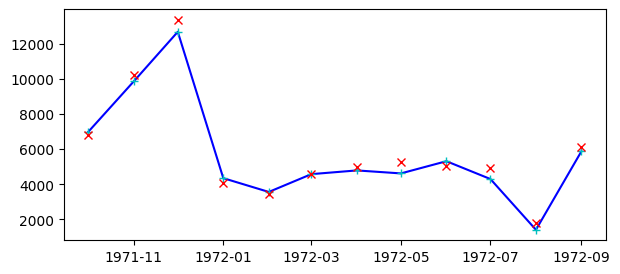

In [50]:
fig, ax = plt.subplots(figsize=(7, 3))
ax = plt.plot(test['y'], '-b')
ax = plt.plot(test['y'], '+c')
ax = plt.plot(test.index, predictions, 'xr')

We observe that the model obtains quite acceptable predictions with an RMSE error of 395.779.

## **Prophet Model**

In [55]:
# Se valida que las columnas del DataFrame "train" sean correctas para el modelo Prophet:
print("Columnas del DataFrame 'train':")
train.columns
train.index

Columnas del DataFrame 'train':


DatetimeIndex(['1964-01-01', '1964-02-01', '1964-03-01', '1964-04-01',
               '1964-05-01', '1964-06-01', '1964-07-01', '1964-08-01',
               '1964-09-01', '1964-10-01', '1964-11-01', '1964-12-01',
               '1965-01-01', '1965-02-01', '1965-03-01', '1965-04-01',
               '1965-05-01', '1965-06-01', '1965-07-01', '1965-08-01',
               '1965-09-01', '1965-10-01', '1965-11-01', '1965-12-01',
               '1966-01-01', '1966-02-01', '1966-03-01', '1966-04-01',
               '1966-05-01', '1966-06-01', '1966-07-01', '1966-08-01',
               '1966-09-01', '1966-10-01', '1966-11-01', '1966-12-01',
               '1967-01-01', '1967-02-01', '1967-03-01', '1967-04-01',
               '1967-05-01', '1967-06-01', '1967-07-01', '1967-08-01',
               '1967-09-01', '1967-10-01', '1967-11-01', '1967-12-01',
               '1968-01-01', '1968-02-01', '1968-03-01', '1968-04-01',
               '1968-05-01', '1968-06-01', '1968-07-01', '1968-08-01',
      

In [93]:
# Volvemos a definir el DataFrame "train" para Prophet:
train = df.iloc[0:-12,:]
test = df.iloc[-12:,:]
# Aplicamos el modelo Facebbok-Prophet a nuestros datos:
model = Prophet(seasonality_mode='multiplicative',
                yearly_seasonality=True,
                changepoint_prior_scale=0.2,   # Controla la flexibilidad de la componente Trend, mayor valor mayores fluctuaciones.
                seasonality_prior_scale=15)    # Controla la estacionalidad, mayor el valor, mayor flexibilidad en la estacionalidad.
model.fit(train)

00:00:26 - cmdstanpy - INFO - Chain [1] start processing
00:00:27 - cmdstanpy - INFO - Chain [1] done processing


In [94]:
# Calculamos el error RMSE:

from sklearn.metrics import root_mean_squared_error

pred_FP = model.predict(test)['yhat']
rmse_FP = root_mean_squared_error(test['y'], pred_FP)
print('\nError-Modelo-FacebookProphet: RMSE: %.3f' % rmse_FP)


Error-Modelo-FacebookProphet: RMSE: 469.224


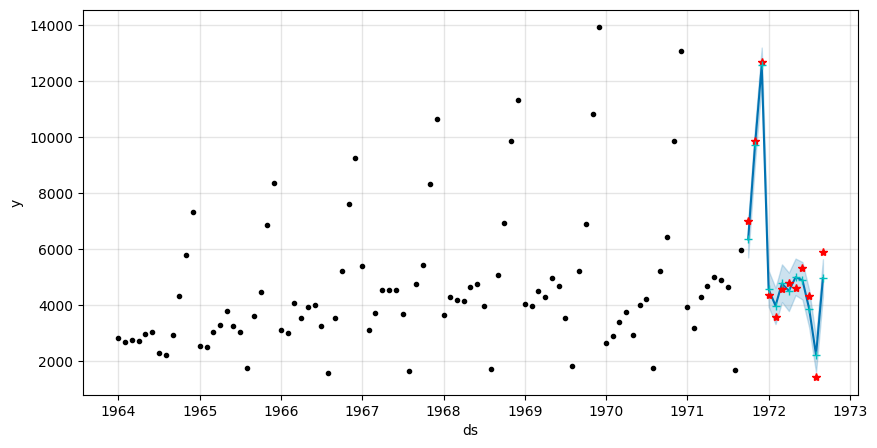

In [74]:
forecast = model.predict(test)

fig, ax = plt.subplots(figsize=(10, 5))
model.plot(forecast, ax=ax)               # Las predicciones se muestran con la línea continua, junto con su región de variabilidad de la predicción.
ax = plt.plot(test['ds'], test['y'], '*r')   # Agregamos los datos de prueba (Test) con puntos rojos, para observar la diferencia.
ax = plt.plot(test['ds'], forecast['yhat'], '+c')    # Valores reales.